In [1]:
from os.path import join
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, zscore
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from ctf_dataset.load import create_wrapped_dataset
from coupling_metrics import cvisc, joint_cvisc, nested_cvisc
from statistical_tests import fisher_mean

In [2]:
base_dir = '/jukebox/hasson/snastase/social-ctf'
data_dir = join(base_dir, 'data_v1')
wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual_v2.hdf5")

sns.set(context='notebook', style='white')
palette = sns.color_palette(['.65', 'darkgoldenrod'])

In [3]:
# Load train/test PCA folds
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_lstms = 512
n_pcs = 142

map_id = slice(None)
matchup_id = 0
repeat_id = 0
player_id = slice(None)

player_teammate = {0: 1, 1: 0, 2: 3, 3: 2}
player_opponents = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}

# negative lags: teammate precedes player / player remembers teammate's past states (i.e., 150 or -10)
# positive lags: player precedes teammate / player predicts teammate's future states (i.e., -150 or 10)
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

In [ ]:
# Run intersubject encoding/decoding analysis
lag_scores = {'score': [], 'lag': [], 'test map': [],
              'target': [], 'PC': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    lstms_train = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    lstms_test = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    lstms_train = np.stack(np.split(np.stack(np.split(
        lstms_train, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    lstms_test = np.stack(np.split(lstms_test, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):

        train_targets = {'teammate': lstms_train[..., player_teammate[player_id], :, :],
                         'opponents': np.moveaxis(lstms_train[
                             ..., player_opponents[player_id], :, :], 1, 0)}
        test_targets = {'teammate': lstms_test[..., player_teammate[player_id], :, :],
                        'opponents': lstms_test[..., player_opponents[player_id], :, :]}

        for target_label in train_targets.keys():
            if target_label is not 'opponents':
                train_stack = np.expand_dims(train_targets[target_label], axis=0)
                test_stack = np.expand_dims(test_targets[target_label], axis=0)
            else:
                train_stack = train_targets[target_label]
                test_stack = test_targets[target_label]
            
            for targets_train, targets_test in zip(train_stack, test_stack):
                for lag in lags.keys():
                    scores = cvisc(lstms_train[..., player_id, :, :],
                                   lstms_test[..., player_id, :, :],
                                   targets_train, targets_test, lag=lag)
                    lag_scores['score'].extend(scores)
                    lag_scores['lag'].extend([lags[lag]] * len(scores))
                    lag_scores['test map'].extend([test_map] * len(scores))
                    lag_scores['target'].extend([target_label] * len(scores))
                    lag_scores['PC'].extend(np.arange(n_pcs))
                    lag_scores['player'].extend([player_id] * len(scores))
                    print(f"player {player_id} {target_label} prediction "
                          f"lag {lag} r = {np.mean(scores):.3f} (test map {test_map})")
        
scores_df = pd.DataFrame(lag_scores)
scores_df.to_csv(f'results/ise-cvpca_matchup-{matchup_id}_results.csv', index=False)

player 0 teammate prediction lag 150 r = 0.041 (test map 0)


In [4]:
# Load in finished results dataframe
scores_df = pd.read_csv(f'results/ise-cvpca_matchup-{matchup_id}_results.csv')
scores_df

,score,lag,test map,target,PC,player
0,0.021218,-10,0,teammate,0,0
1,0.037363,-10,0,teammate,1,0
2,0.026215,-10,0,teammate,2,0
3,0.109048,-10,0,teammate,3,0
4,0.089952,-10,0,teammate,4,0
...,...,...,...,...,...,...
381691,-0.063856,10,31,opponents,137,3
381692,-0.046017,10,31,opponents,138,3
381693,0.025087,10,31,opponents,139,3
381694,-0.107039,10,31,opponents,140,3


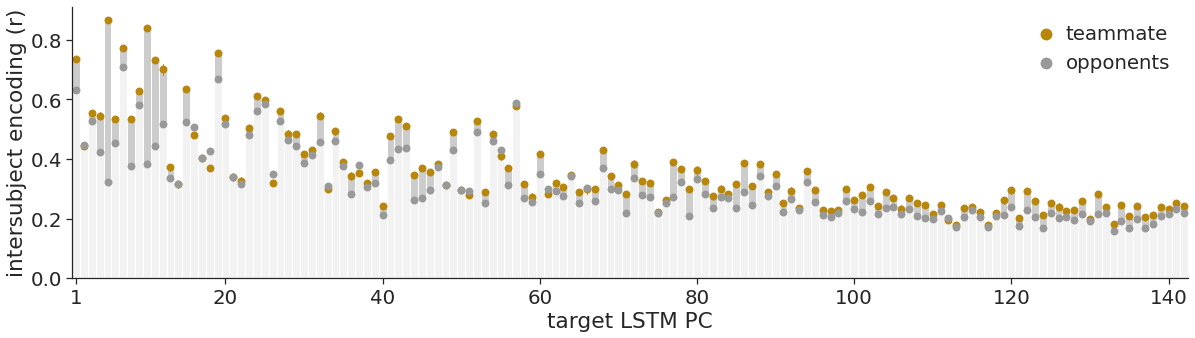

In [5]:
lag = 0
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.8)
bar_width = 1
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'teammate')],
            ci=None, color='.8', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'opponents')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
for patch in ax.patches:
    curr_width = patch.get_width()
    diff_width = curr_width - bar_width
    patch.set_width(bar_width)
    patch.set_x(patch.get_x() + diff_width * .5)
sns.pointplot(x='PC', y='score', hue='target',
              data=scores_df[(scores_df['lag'] == lag)],
              join=False, ax=ax, scale=.9, errwidth=1,
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='target LSTM PC', ylabel='intersubject encoding (r)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [100]
l.legendHandles[1]._sizes = [100]
sns.despine()
plt.savefig(f'figures/ise_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

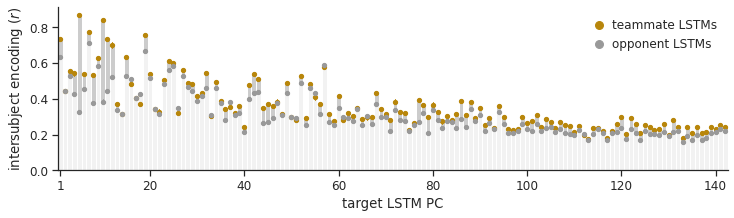

In [6]:
lag = 0
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.1)
bar_width = 1
fig, ax = plt.subplots(figsize=(12, 3))
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'teammate')],
            ci=None, color='.8', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'opponents')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
for patch in ax.patches:
    curr_width = patch.get_width()
    diff_width = curr_width - bar_width
    patch.set_width(bar_width)
    patch.set_x(patch.get_x() + diff_width * .5)
sns.pointplot(x='PC', y='score', hue='target',
              data=scores_df[(scores_df['lag'] == lag)],
              join=False, ax=ax, scale=.6, errwidth=1,
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='target LSTM PC', ylabel='intersubject encoding ($\it{r}$)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
handles, labels = ax.get_legend_handles_labels()
labels = ['teammate LSTMs', 'opponent LSTMs']
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [60]
l.legendHandles[1]._sizes = [60]
sns.despine()
plt.savefig(f'figures/ise_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

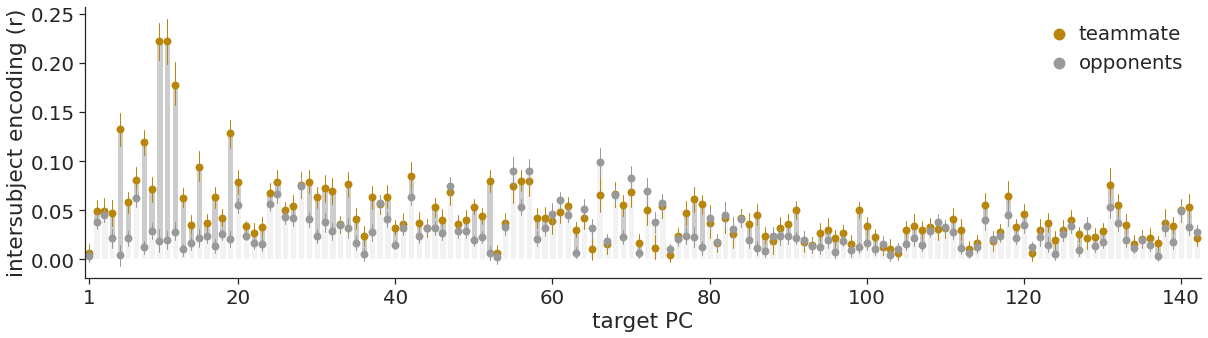

In [7]:
lag = -10
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.8)
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'teammate')],
            ci=None, color='.8', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'opponents')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
sns.pointplot(x='PC', y='score', hue='target',
              data=scores_df[(scores_df['lag'] == lag)],
              join=False, ax=ax, scale=.9, errwidth=1,
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='target PC', ylabel='intersubject encoding (r)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [100]
l.legendHandles[1]._sizes = [100]
sns.despine()
plt.savefig(f'figures/ise_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

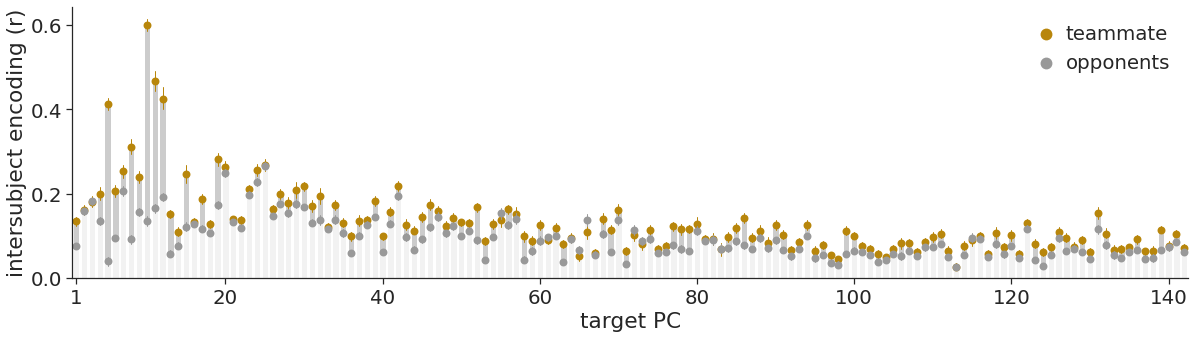

In [8]:
lag = -5
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.8)
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'teammate')],
            ci=None, color='.8', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'opponents')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
sns.pointplot(x='PC', y='score', hue='target',
              data=scores_df[(scores_df['lag'] == lag)],
              join=False, ax=ax, scale=.9, errwidth=1,
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='target PC', ylabel='intersubject encoding (r)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [100]
l.legendHandles[1]._sizes = [100]
sns.despine()
plt.savefig(f'figures/ise_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

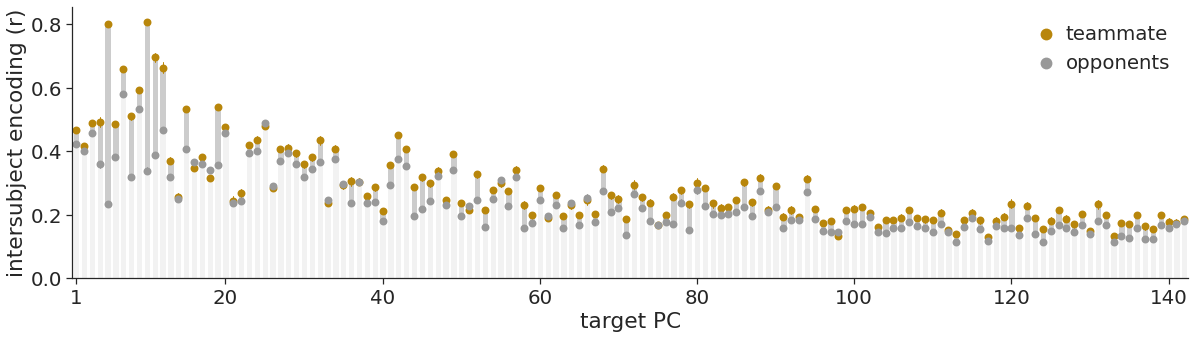

In [9]:
lag = -1
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.8)
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'teammate')],
            ci=None, color='.8', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'opponents')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
sns.pointplot(x='PC', y='score', hue='target',
              data=scores_df[(scores_df['lag'] == lag)],
              join=False, ax=ax, scale=.9, errwidth=1,
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='target PC', ylabel='intersubject encoding (r)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [100]
l.legendHandles[1]._sizes = [100]
sns.despine()
plt.savefig(f'figures/ise_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

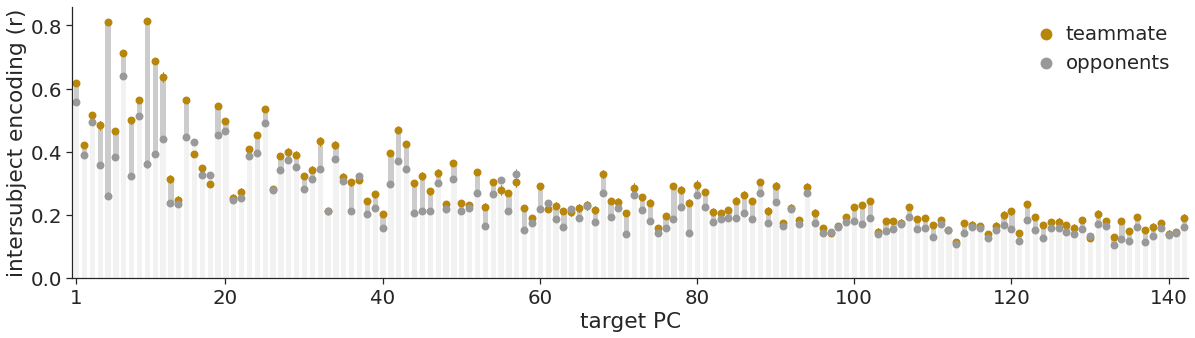

In [10]:
lag = 1
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.8)
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'teammate')],
            ci=None, color='.8', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'opponents')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
sns.pointplot(x='PC', y='score', hue='target',
              data=scores_df[(scores_df['lag'] == lag)],
              join=False, ax=ax, scale=.9, errwidth=1,
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='target PC', ylabel='intersubject encoding (r)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [100]
l.legendHandles[1]._sizes = [100]
sns.despine()
plt.savefig(f'figures/ise_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

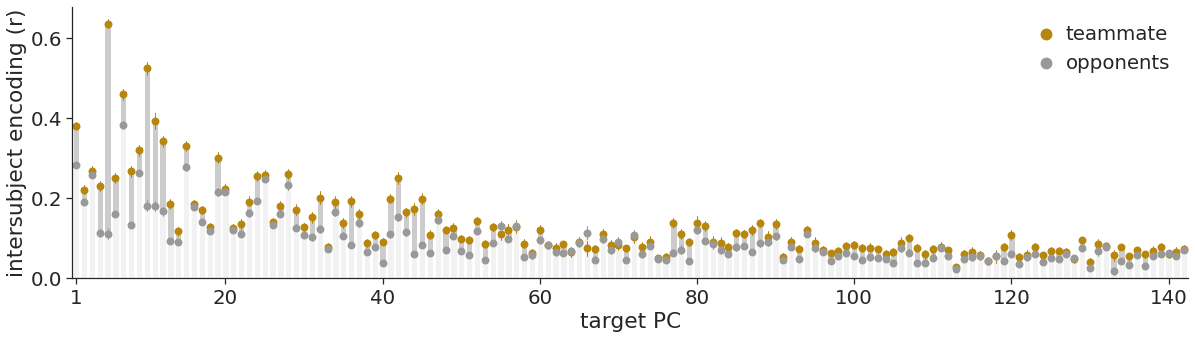

In [11]:
lag = 5
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.8)
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'teammate')],
            ci=None, color='.8', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'opponents')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
sns.pointplot(x='PC', y='score', hue='target',
              data=scores_df[(scores_df['lag'] == lag)],
              join=False, ax=ax, scale=.9, errwidth=1,
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='target PC', ylabel='intersubject encoding (r)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [100]
l.legendHandles[1]._sizes = [100]
sns.despine()
plt.savefig(f'figures/ise_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

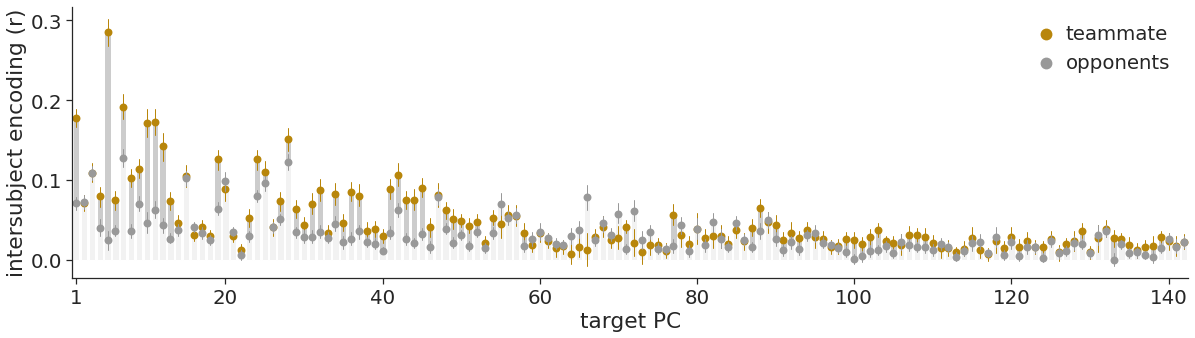

In [12]:
lag = 10
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.8)
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'teammate')],
            ci=None, color='.8', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['target'] == 'opponents')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
sns.pointplot(x='PC', y='score', hue='target',
              data=scores_df[(scores_df['lag'] == lag)],
              join=False, ax=ax, scale=.9, errwidth=1,
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='target PC', ylabel='intersubject encoding (r)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [100]
l.legendHandles[1]._sizes = [100]
sns.despine()
plt.savefig(f'figures/ise_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

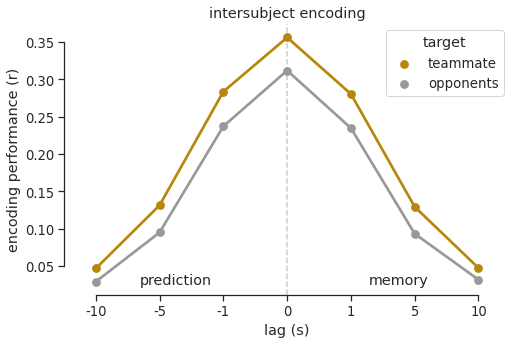

In [13]:
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 5))

sns.pointplot(x='lag', y='score', hue='target',
              data=scores_df.groupby(
                  ['lag', 'test map', 'target', 'player']
              ).mean().reset_index(), ax=ax,
              hue_order=['teammate', 'opponents'],
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='lag (s)', ylabel='encoding performance (r)',
       title='intersubject encoding')
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
sns.despine(trim=True)

<AxesSubplot:xlabel='lag', ylabel='score'>

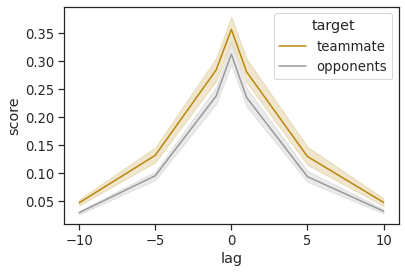

In [14]:
sns.lineplot(x='lag', y='score', hue='target',
              data=scores_df.groupby(
                  ['lag', 'target', 'PC']
              ).mean().reset_index(),
              hue_order=['teammate', 'opponents'],
              palette=sns.color_palette(palette, 2))

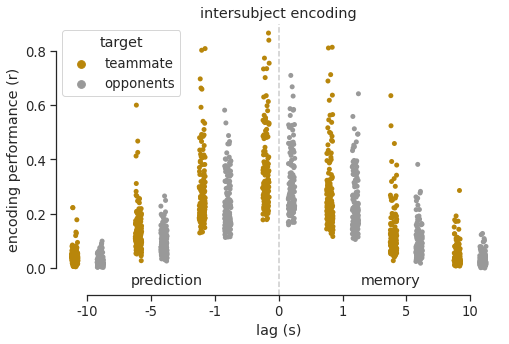

In [15]:
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 5))

sns.stripplot(x='lag', y='score', hue='target',
              data=scores_df.groupby(
                  ['lag', 'target', 'PC']
              ).mean().reset_index(), ax=ax, dodge=True,
              hue_order=['teammate', 'opponents'],
              palette=sns.color_palette(palette, 2))

ax.set(xlabel='lag (s)', ylabel='encoding performance (r)',
       title='intersubject encoding', ylim=(-.1, .9))
ax.axvline(3, c='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
sns.despine(trim=True)

In [16]:
scores_df = pd.read_csv(f'results/ise-cvpca_matchup-{matchup_id}_results.csv')
mapper = {-10: 0, -5: 1, -1: 2, 0: 3, 1: 4, 5: 5, 10: 6}
scores_df['lag'].replace(mapper, inplace=True)
scores_df = scores_df.groupby(['lag', 'target', 'PC']).mean().reset_index()

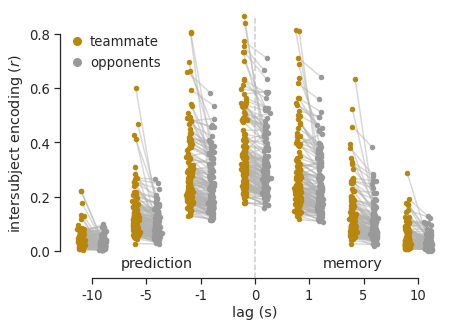

In [17]:
from matplotlib.lines import Line2D

palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.2)
fig, ax = plt.subplots(figsize=(7, 5))

scores_t = scores_df[scores_df['target'] == 'teammate']
scores_o = scores_df[scores_df['target'] == 'opponents']

lags_t = scores_t.copy()
lags_o = scores_o.copy()
lags_t['lag'] = scores_t['lag'] + np.random.randn(len(scores_t)) / 40 - .2
lags_o['lag'] = scores_o['lag'] + np.random.randn(len(scores_o)) / 40 + .2

ax.scatter(lags_t['lag'], scores_t['score'],
           c='darkgoldenrod', s=20)

ax.scatter(lags_o['lag'], scores_o['score'],
           c='.6', s=20)

for lag in np.arange(7):
    plt.plot(np.vstack((lags_t[scores_t['lag'] == lag]['lag'],
                        lags_o[scores_o['lag'] == lag]['lag'])),
             np.vstack((scores_t[scores_t['lag'] == lag]['score'],
                        scores_o[scores_o['lag'] == lag]['score'])),
             c='.7', alpha=.5, zorder=0)

ax.set(xlabel='lag (s)', ylabel='intersubject encoding ($\it{r}$)', ylim=(-.1, .9))
ax.set_xticks([0, 1, 2, 3, 4, 5, 6]),
ax.set_xticklabels([-10, -5, -1, 0, 1, 5, 10])
ax.vlines(3, -.1, .86, color='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
tpoint = Line2D([0], [0], label='teammate', marker='o', markersize=9, 
         markeredgecolor='none', markerfacecolor='darkgoldenrod', linestyle='')
opoint = Line2D([0], [0], label='opponents', marker='o', markersize=9, 
         markeredgecolor='none', markerfacecolor='.6', linestyle='')
plt.legend(handles=[tpoint, opoint], frameon=False, handletextpad=0,
               loc='upper left', bbox_to_anchor=(-.02, .94))
sns.despine(trim=True)
plt.savefig(f'figures/ise_all-lags_data-v1_point.svg', dpi=300, bbox_inches='tight', transparent=True)

In [18]:
# Run intersubject encoding/decoding analysis
predictors = 'opponents' # teammate or opponents
cvisc_scores = {'score': [], 'lag': [],
                'test map': [], 'PC': [], 'player': []}

# Switch lags for predicting player from teammate/opponent
# negative lags: teammate precedes player / player encodes teammate's future states (prediction)
# positive lags: player precedes teammate / player encodes teammate's past states (memory)
lags = {150: -10, 75: -5, 15: -1, 0: 0, -15: 1, -75: 5, -150: 10}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    lstms_train = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    lstms_test = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    lstms_train = np.stack(np.split(np.stack(np.split(
        lstms_train, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    lstms_test = np.stack(np.split(lstms_test, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):
        
        train_targets_orig = lstms_train[..., player_id, :, :]
        test_targets_orig = lstms_test[..., player_id, :, :]
        
        if predictors == 'teammate':
            train_samples_orig = lstms_train[..., player_teammate[player_id], :, :]
            test_samples_orig = lstms_test[..., player_teammate[player_id], :, :]
        elif predictors == 'opponents':
            train_samples_orig = np.concatenate((
                lstms_train[..., player_opponents[player_id][0], :, :],
                lstms_train[..., player_opponents[player_id][1], :, :]), axis=-1)
            test_samples_orig = np.concatenate((
                lstms_test[..., player_opponents[player_id][0], :, :],
                lstms_test[..., player_opponents[player_id][1], :, :]), axis=-1)
        
        for lag in lags.keys():
            if not lag or lag == 0:
                train_samples = train_samples_orig
                train_targets = train_targets_orig
                test_samples = test_samples_orig
                test_targets = test_targets_orig

            elif lag > 0:
                train_samples = train_samples_orig[..., :-lag, :]
                train_targets = train_targets_orig[..., lag:, :]
                test_samples = test_samples_orig[..., :-lag, :]
                test_targets = test_targets_orig[..., lag:, :]

            elif lag < 0:
                train_samples = train_samples_orig[..., -lag:, :]
                train_targets = train_targets_orig[..., :lag, :]
                test_samples = test_samples_orig[..., -lag:, :]
                test_targets = test_targets_orig[..., :lag, :]

            train_samples = train_samples.reshape((-1, train_samples.shape[-1]))
            test_samples = test_samples.reshape((-1, test_samples.shape[-1]))
            train_targets = train_targets.reshape((-1, train_targets.shape[-1]))
            test_targets = test_targets.reshape((-1, test_targets.shape[-1]))

            scores = cvisc(train_samples, test_samples,
                           train_targets, test_targets,
                           n_targets=n_pcs,
                           scorer=pearsonr)
            cvisc_scores['score'].extend(scores)
            cvisc_scores['lag'].extend([lags[lag]] * n_pcs)
            cvisc_scores['test map'].extend([test_map] * n_pcs)
            cvisc_scores['PC'].extend(np.arange(n_pcs))
            cvisc_scores['player'].extend([player_id] * n_pcs)
            for l, ss in zip(['score'], [scores]):
                print(f"player {player_id} lag {lag} "
                      f"{l} r = {[f'{s:.2f}' for s in ss[:8]]} "
                      f"(test map {test_map})")
        
scores_df = pd.DataFrame(cvisc_scores)
scores_df.to_csv(f'results/cvisc-{predictors}_lags_matchup-{matchup_id}_results.csv', index=False)

player 0 lag 150 score r = ['0.01', '0.06', '0.06', '0.10', '0.11', '0.10', '0.20', '-0.02'] (test map 0)
player 0 lag 75 score r = ['0.01', '0.02', '0.15', '0.12', '0.02', '0.11', '0.31', '-0.06'] (test map 0)
player 0 lag 15 score r = ['0.38', '0.42', '0.45', '0.46', '0.35', '0.40', '0.60', '0.22'] (test map 0)
player 0 lag 0 score r = ['0.59', '0.47', '0.53', '0.55', '0.47', '0.46', '0.71', '0.32'] (test map 0)
player 0 lag -15 score r = ['0.54', '0.40', '0.46', '0.49', '0.38', '0.42', '0.66', '0.27'] (test map 0)
player 0 lag -75 score r = ['0.27', '0.21', '0.22', '0.11', '0.26', '0.18', '0.40', '0.14'] (test map 0)
player 0 lag -150 score r = ['0.08', '0.04', '0.16', '0.02', '0.05', '0.08', '0.16', '0.12'] (test map 0)
player 1 lag 150 score r = ['0.11', '-0.00', '-0.01', '0.01', '0.06', '0.01', '0.14', '0.08'] (test map 0)
player 1 lag 75 score r = ['0.04', '0.18', '0.08', '0.27', '-0.01', '0.11', '0.21', '0.10'] (test map 0)
player 1 lag 15 score r = ['0.42', '0.46', '0.42', '0.

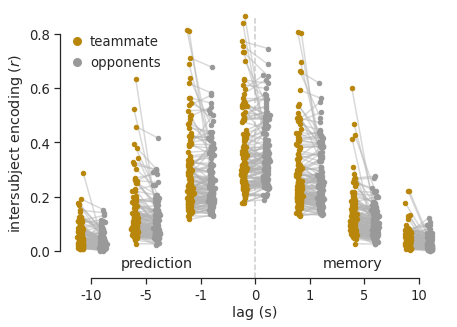

In [18]:
teammate_df = pd.read_csv(f'results/cvisc-teammate_lags_matchup-{matchup_id}_results.csv')
teammate_df['predictors'] = 'teammate'

opponents_df = pd.read_csv(f'results/cvisc-opponents_lags_matchup-{matchup_id}_results.csv')
opponents_df['predictors'] = 'opponents'

scores_df = pd.concat((teammate_df, opponents_df))

# Flip these around to put prediction on left, memory on right
mapper = {10: 0, 5: 1, 1: 2, 0: 3, -1: 4, -5: 5, -10: 6}
scores_df['lag'].replace(mapper, inplace=True)
scores_df = scores_df.groupby(['lag', 'predictors', 'PC']).mean().reset_index()

from matplotlib.lines import Line2D

palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.2)
fig, ax = plt.subplots(figsize=(7, 5))

scores_t = scores_df[scores_df['predictors'] == 'teammate']
scores_o = scores_df[scores_df['predictors'] == 'opponents']

lags_t = scores_t.copy()
lags_o = scores_o.copy()
lags_t['lag'] = scores_t['lag'] + np.random.randn(len(scores_t)) / 40 - .2
lags_o['lag'] = scores_o['lag'] + np.random.randn(len(scores_o)) / 40 + .2

ax.scatter(lags_t['lag'], scores_t['score'],
           c='darkgoldenrod', s=20)

ax.scatter(lags_o['lag'], scores_o['score'],
           c='.6', s=20)

for lag in np.arange(7):
    plt.plot(np.vstack((lags_t[scores_t['lag'] == lag]['lag'],
                        lags_o[scores_o['lag'] == lag]['lag'])),
             np.vstack((scores_t[scores_t['lag'] == lag]['score'],
                        scores_o[scores_o['lag'] == lag]['score'])),
             c='.7', alpha=.5, zorder=0)

ax.set(xlabel='lag (s)', ylabel='intersubject encoding ($\it{r}$)', ylim=(-.1, .9))
ax.set_xticks([0, 1, 2, 3, 4, 5, 6]),
ax.set_xticklabels([-10, -5, -1, 0, 1, 5, 10])
ax.vlines(3, -.1, .86, color='.8', ls='--', zorder=0)
ax.annotate('prediction', xy=(.25, 0.04), xycoords='axes fraction', ha='center')
ax.annotate('memory', xy=(.75, 0.04), xycoords='axes fraction', ha='center')
tpoint = Line2D([0], [0], label='teammate', marker='o', markersize=9, 
         markeredgecolor='none', markerfacecolor='darkgoldenrod', linestyle='')
opoint = Line2D([0], [0], label='opponents', marker='o', markersize=9, 
         markeredgecolor='none', markerfacecolor='.6', linestyle='')
plt.legend(handles=[tpoint, opoint], frameon=False, handletextpad=0,
           loc='upper left', bbox_to_anchor=(-.02, .94))
sns.despine(trim=True)
plt.savefig(f'figures/cvisc_lags-all_data-v1_point.svg', dpi=300, bbox_inches='tight', transparent=True)

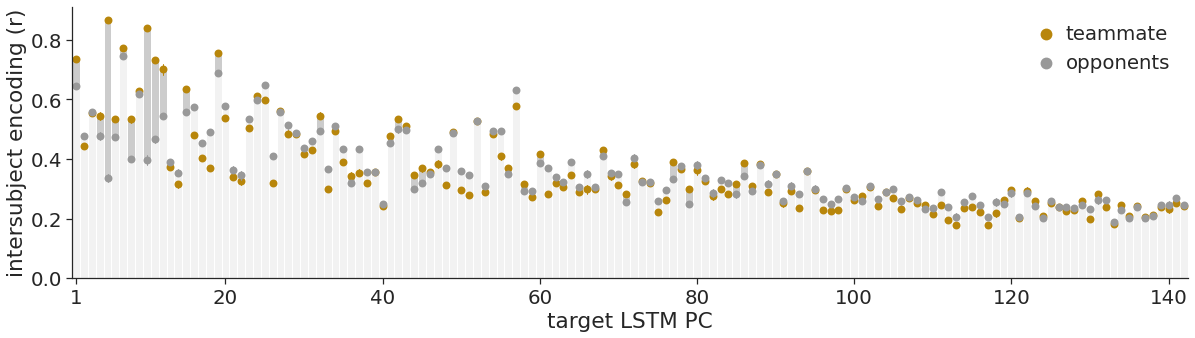

In [19]:
teammate_df = pd.read_csv(f'results/cvisc-teammate_lags_matchup-{matchup_id}_results.csv')
teammate_df['predictors'] = 'teammate'

opponents_df = pd.read_csv(f'results/cvisc-opponents_lags_matchup-{matchup_id}_results.csv')
opponents_df['predictors'] = 'opponents'

scores_df = pd.concat((teammate_df, opponents_df))

lag = 0
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.8)
bar_width = 1
fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['predictors'] == 'teammate')],
            ci=None, color='.8', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score',
            data=scores_df[(scores_df['lag'] == lag) &
                           (scores_df['predictors'] == 'opponents')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
for patch in ax.patches:
    curr_width = patch.get_width()
    diff_width = curr_width - bar_width
    patch.set_width(bar_width)
    patch.set_x(patch.get_x() + diff_width * .5)
sns.pointplot(x='PC', y='score', hue='predictors',
              data=scores_df[(scores_df['lag'] == lag)],
              join=False, ax=ax, scale=.9, errwidth=1,
              palette=sns.color_palette(palette, 2))
ax.set(xlabel='target LSTM PC', ylabel='intersubject encoding (r)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [100]
l.legendHandles[1]._sizes = [100]
sns.despine()
plt.savefig(f'figures/ise_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
# Run joint intersubject encoding/decoding analysis
cvisc_scores = {'joint score': [], 'teammate score': [],
                'opponent score': [], 'lag': [],
                'test map': [], 'PC': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    lstms_train = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    lstms_test = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    lstms_train = np.stack(np.split(np.stack(np.split(
        lstms_train, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    lstms_test = np.stack(np.split(lstms_test, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):
        
        train_targets_orig = lstms_train[..., player_id, :, :]
        test_targets_orig = lstms_test[..., player_id, :, :]
        
        #train_samples = np.concatenate((
        #    lstms_train[..., player_teammate[player_id], :, :],
        #    lstms_train[..., player_opponents[player_id][0], :, :],
        #    lstms_train[..., player_opponents[player_id][1], :, :]), axis=-1)
        
        #test_samples = np.concatenate((
        #    lstms_test[..., player_teammate[player_id], :, :],
        #    lstms_test[..., player_opponents[player_id][0], :, :],
        #    lstms_test[..., player_opponents[player_id][1], :, :]), axis=-1)
        
        train_samples_orig = np.concatenate((
            lstms_train[..., player_teammate[player_id], :, :],
            lstms_train[..., player_opponents[player_id][0], :, :],
            lstms_train[..., player_opponents[player_id][1], :, :]), axis=-1)
        
        test_samples_orig = np.concatenate((
            lstms_test[..., player_teammate[player_id], :, :],
            lstms_test[..., player_opponents[player_id][0], :, :],
            lstms_test[..., player_opponents[player_id][1], :, :]), axis=-1)
        
        #train_samples = train_samples.reshape((-1, train_samples.shape[-1]))
        #test_samples = test_samples.reshape((-1, test_samples.shape[-1]))
        #train_targets = train_targets.reshape((-1, train_targets.shape[-1]))
        #test_targets = test_targets.reshape((-1, test_targets.shape[-1]))

        for lag in lags.keys():
        #for lag in [0]:
        
            if not lag or lag == 0:
                train_samples = train_samples_orig
                train_targets = train_targets_orig
                test_samples = test_samples_orig
                test_targets = test_targets_orig

            elif lag > 0:
                train_samples = train_samples_orig[..., :-lag, :]
                train_targets = train_targets_orig[..., lag:, :]
                test_samples = test_samples_orig[..., :-lag, :]
                test_targets = test_targets_orig[..., lag:, :]

            elif lag < 0:
                train_samples = train_samples_orig[..., -lag:, :]
                train_targets = train_targets_orig[..., :lag, :]
                test_samples = test_samples_orig[..., -lag:, :]
                test_targets = test_targets_orig[..., :lag, :]

            train_samples = train_samples.reshape((-1, train_samples.shape[-1]))
            test_samples = test_samples.reshape((-1, test_samples.shape[-1]))
            train_targets = train_targets.reshape((-1, train_targets.shape[-1]))
            test_targets = test_targets.reshape((-1, test_targets.shape[-1]))
                
            scores = joint_cvisc(train_samples, test_samples,
                                 train_targets, test_targets,
                                 teammate_width=142,
                                 opponent_width=284,
                                 n_targets=n_pcs,
                                 scorer=pearsonr)
            (joint_scores, teammate_scores, opponent_scores) = scores
            cvisc_scores['joint score'].extend(joint_scores)
            cvisc_scores['teammate score'].extend(teammate_scores)
            cvisc_scores['opponent score'].extend(opponent_scores)
            cvisc_scores['lag'].extend([lags[lag]] * n_pcs)
            cvisc_scores['test map'].extend([test_map] * n_pcs)
            cvisc_scores['PC'].extend(np.arange(n_pcs))
            cvisc_scores['player'].extend([player_id] * n_pcs)
            for l, ss in zip(['joint', 'teammate', 'opponent'],
                             [joint_scores, teammate_scores, opponent_scores]):
                print(f"player {player_id} lag {lag} "
                      f"{l} r = {[f'{s:.2f}' for s in ss[:8]]} "
                      f"(test map {test_map})")
        
scores_df = pd.DataFrame(cvisc_scores)
scores_df.to_csv(f'results/cvisc-joint_lags-all_matchup-{matchup_id}_results.csv', index=False)

player 0 lag 150 joint r = ['-0.00', '0.05', '0.02', '0.14', '0.13', '0.13', '0.13', '0.04'] (test map 0)
player 0 lag 150 teammate r = ['-0.17', '0.00', '-0.09', '0.07', '0.12', '0.05', '-0.06', '0.07'] (test map 0)
player 0 lag 150 opponent r = ['0.13', '0.05', '0.08', '0.10', '0.03', '0.10', '0.18', '-0.04'] (test map 0)
player 0 lag 75 joint r = ['0.09', '0.05', '0.19', '0.27', '0.38', '0.20', '0.27', '0.14'] (test map 0)
player 0 lag 75 teammate r = ['0.12', '0.05', '0.09', '0.09', '0.38', '0.08', '0.04', '0.17'] (test map 0)
player 0 lag 75 opponent r = ['0.00', '0.00', '0.15', '0.16', '-0.03', '0.13', '0.24', '-0.02'] (test map 0)
player 0 lag 15 joint r = ['0.55', '0.50', '0.50', '0.64', '0.80', '0.52', '0.72', '0.45'] (test map 0)
player 0 lag 15 teammate r = ['0.14', '0.08', '0.16', '0.25', '0.65', '0.23', '0.52', '0.35'] (test map 0)
player 0 lag 15 opponent r = ['0.37', '0.42', '0.42', '0.43', '0.38', '0.38', '0.56', '0.23'] (test map 0)
player 0 lag 0 joint r = ['0.90', '0

In [26]:
scores_df = pd.read_csv(f'results/cvisc-joint_lags-all_matchup-{matchup_id}_results.csv')

behav_values = ['joint score', 'teammate score', 'opponent score']
scores_melt = scores_df.melt(
    id_vars=['lag', 'test map', 'PC', 'player'],
    value_vars=behav_values, var_name='predictor',
    value_name='score')
rename_behav = {b:b.split(' ')[0] for b in behav_values}
scores_melt.replace(to_replace=rename_behav, inplace=True)
scores_df

,joint score,teammate score,opponent score,lag,test map,PC,player
0,-0.002976,-0.166223,0.125205,-10,0,0,0
1,0.053367,0.004524,0.054850,-10,0,1,0
2,0.021417,-0.087882,0.081884,-10,0,2,0
3,0.140239,0.065398,0.101459,-10,0,3,0
4,0.125171,0.115228,0.029011,-10,0,4,0
...,...,...,...,...,...,...,...
127227,0.188679,0.147399,0.114718,10,31,137,3
127228,0.039955,0.090789,-0.051128,10,31,138,3
127229,-0.090640,-0.176235,0.045099,10,31,139,3
127230,0.135627,0.156822,0.005439,10,31,140,3


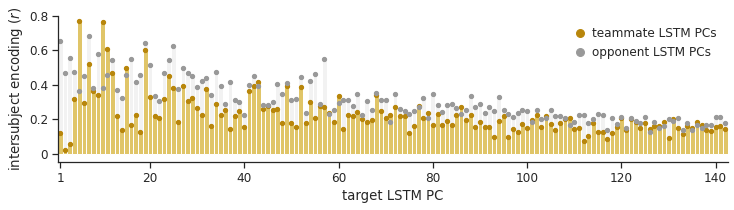

In [94]:
lag = 0
palette = ['darkgoldenrod', '.6']

sns.set(style='ticks', font_scale=1.1)
bar_width = 1
fig, ax = plt.subplots(figsize=(12, 2.7))
#fig, ax = plt.subplots(figsize=(12, 2))
sns.barplot(x='PC', y='score', estimator=fisher_mean,
            data=scores_melt[(scores_melt['lag'] == lag) &
                             (scores_melt['predictor'] == 'opponent')],
            ci=None, color='.95', zorder=0,
            capsize=0, ax=ax)
sns.barplot(x='PC', y='score', estimator=fisher_mean,
            data=scores_melt[(scores_melt['lag'] == lag) &
                             (scores_melt['predictor'] == 'teammate')],
            ci=None, color='xkcd:maize', zorder=0,
            capsize=0, ax=ax)
for patch in ax.patches:
    curr_width = patch.get_width()
    diff_width = curr_width - bar_width
    patch.set_width(bar_width)
    patch.set_x(patch.get_x() + diff_width * .5)
sns.pointplot(x='PC', y='score', hue='predictor', scale=.6, legend=False,
              data=scores_melt[(scores_melt['lag'] == lag) &
                               ((scores_melt['predictor'] == 'teammate') |
                                (scores_melt['predictor'] == 'opponent'))],
              join=False, ax=ax, errwidth=0, capsize=0,
              palette=sns.color_palette(palette, 3),
              estimator=fisher_mean)
ax.set(xlabel='target LSTM PC', ylim=(-.05, .8), ylabel='intersubject encoding ($\it{r}$)')
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
ax.set_yticks([0, .2, .4, .6, .8])
ax.set_yticklabels([0, .2, .4, .6, .8])
handles, labels = ax.get_legend_handles_labels()
labels = ['teammate LSTM PCs', 'opponent LSTM PCs']
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
l.legendHandles[0]._sizes = [60]
l.legendHandles[1]._sizes = [60]
sns.despine()
plt.savefig(f'figures/joint-cvisc_joint_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
# Run nested intersubject encoding/decoding analysis
# Isolate unique teammate variance
cvisc_scores = {'joint score': [], 'nested score': [],
                'lag': [], 'test map': [],
                'PC': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    lstms_train = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    lstms_test = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    lstms_train = np.stack(np.split(np.stack(np.split(
        lstms_train, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    lstms_test = np.stack(np.split(lstms_test, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):
        
        train_targets_orig = lstms_train[..., player_id, :, :]
        test_targets_orig = lstms_test[..., player_id, :, :]
        
        train_samples_orig = np.concatenate((
            lstms_train[..., player_teammate[player_id], :, :],
            lstms_train[..., player_opponents[player_id][0], :, :],
            lstms_train[..., player_opponents[player_id][1], :, :]), axis=-1)
        
        test_samples_orig = np.concatenate((
            lstms_test[..., player_teammate[player_id], :, :],
            lstms_test[..., player_opponents[player_id][0], :, :],
            lstms_test[..., player_opponents[player_id][1], :, :]), axis=-1)
        
        for lag in lags.keys():
        #for lag in [0]:
        
            if not lag or lag == 0:
                train_samples = train_samples_orig
                train_targets = train_targets_orig
                test_samples = test_samples_orig
                test_targets = test_targets_orig

            elif lag > 0:
                train_samples = train_samples_orig[..., :-lag, :]
                train_targets = train_targets_orig[..., lag:, :]
                test_samples = test_samples_orig[..., :-lag, :]
                test_targets = test_targets_orig[..., lag:, :]

            elif lag < 0:
                train_samples = train_samples_orig[..., -lag:, :]
                train_targets = train_targets_orig[..., :lag, :]
                test_samples = test_samples_orig[..., -lag:, :]
                test_targets = test_targets_orig[..., :lag, :]

            train_samples = train_samples.reshape((-1, train_samples.shape[-1]))
            test_samples = test_samples.reshape((-1, test_samples.shape[-1]))
            train_targets = train_targets.reshape((-1, train_targets.shape[-1]))
            test_targets = test_targets.reshape((-1, test_targets.shape[-1]))
        
            scores = nested_cvisc(train_samples, test_samples,
                                  train_targets, test_targets,
                                  teammate_width=142,
                                  opponent_width=284,
                                  n_targets=n_pcs,
                                  scorer=r2_score)
            (joint_scores, nested_scores) = scores
            cvisc_scores['joint score'].extend(joint_scores)
            cvisc_scores['nested score'].extend(nested_scores)
            cvisc_scores['lag'].extend([lags[lag]] * n_pcs)
            cvisc_scores['test map'].extend([test_map] * n_pcs)
            cvisc_scores['PC'].extend(np.arange(n_pcs))
            cvisc_scores['player'].extend([player_id] * n_pcs)
            for l, ss in zip(['joint', 'nested'],
                             [joint_scores, nested_scores]):
                print(f"player {player_id} lag {lag} "
                      f"{l} r = {[f'{s:.2f}' for s in ss[:8]]} "
                      f"(test map {test_map})")
        
scores_df = pd.DataFrame(cvisc_scores)
scores_df.to_csv(f'results/cvisc-nested_lags-all_matchup-{matchup_id}_results.csv', index=False)

player 0 lag 150 joint r = ['-0.04', '-0.02', '-0.04', '0.01', '-0.03', '0.01', '-0.00', '-0.03'] (test map 0)
player 0 lag 150 nested r = ['-0.02', '-0.01', '-0.01', '0.00', '-0.00', '0.00', '0.04', '-0.03'] (test map 0)
player 0 lag 75 joint r = ['-0.02', '-0.06', '0.02', '0.07', '0.12', '0.04', '0.06', '0.00'] (test map 0)
player 0 lag 75 nested r = ['-0.03', '-0.05', '0.02', '-0.00', '-0.05', '0.01', '0.10', '-0.05'] (test map 0)
player 0 lag 15 joint r = ['0.30', '0.25', '0.25', '0.41', '0.63', '0.27', '0.51', '0.20'] (test map 0)
player 0 lag 15 nested r = ['0.14', '0.17', '0.20', '0.21', '0.13', '0.16', '0.36', '0.04'] (test map 0)
player 0 lag 0 joint r = ['0.80', '0.28', '0.38', '0.55', '0.78', '0.38', '0.70', '0.27'] (test map 0)
player 0 lag 0 nested r = ['0.35', '0.21', '0.28', '0.30', '0.21', '0.21', '0.51', '0.09'] (test map 0)
player 0 lag -15 joint r = ['0.61', '0.21', '0.30', '0.46', '0.66', '0.30', '0.60', '0.18'] (test map 0)
player 0 lag -15 nested r = ['0.29', '0.1

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/ipykernel_launcher.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  app.launch_new_instance()


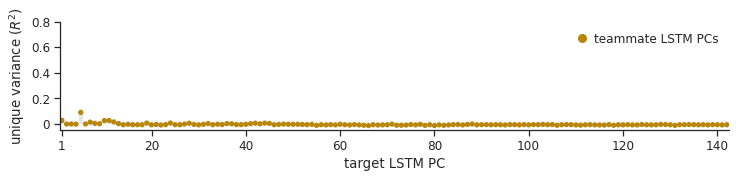

In [93]:
from matplotlib.lines import Line2D

scores_df = pd.read_csv(f'results/cvisc-nested_lags-all_matchup-{matchup_id}_results.csv')

scores_df['unique'] = ((scores_df['joint score'] - 
                        scores_df['nested score']))

lag = 10
bar_width = 1

sns.set(style='ticks', font_scale=1.1)
#fig, ax = plt.subplots(figsize=(20, 4))
#fig, ax = plt.subplots(figsize=(12, 2.5))
fig, ax = plt.subplots(figsize=(12, 2))
sns.barplot(x='PC', y='unique',
            data=scores_df[scores_melt['lag'] == lag],
            ci=None, color='.9', zorder=0,
            capsize=0, ax=ax)
for patch in ax.patches:
    curr_width = patch.get_width()
    diff_width = curr_width - bar_width
    patch.set_width(bar_width)
    patch.set_x(patch.get_x() + diff_width * .5)
sns.pointplot(x='PC', y='unique', errwidth=1,
              data=scores_df[scores_df['lag'] == lag],
              join=False, ax=ax, scale=.6, color='darkgoldenrod',
              legend='full')
ax.set(xlabel='target LSTM PC', ylabel='unique variance ($\it{R}^2$)',
       ylim=(-.05, .8))
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
ax.set_yticks([0, .2, .4, .6, .8])
ax.set_yticklabels([0, .2, .4, .6, .8])
#handles, labels = ax.get_legend_handles_labels()
handles = [Line2D([0], [0], marker='o', markersize=8,
                  linestyle='', color='darkgoldenrod')]
labels = ['teammate LSTM PCs']
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
#l.legendHandles[0]._sizes = [200]
sns.despine()
plt.savefig(f'figures/cvisc-nested_unique_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
# Run nested intersubject encoding/decoding analysis
# Isolate unique opponent variance
cvisc_scores = {'joint score': [], 'nested score': [],
                'lag': [], 'test map': [],
                'PC': [], 'player': []}

for test_map in np.arange(n_maps):
    train_maps = np.array([m for m in np.arange(n_maps) if m != test_map])

    train_repeats = np.tile(np.repeat(np.arange(n_repeats), n_players * n_samples), n_maps - 1)
    test_repeats = np.repeat(np.arange(n_repeats), n_players * n_samples)

    train_shape = ((n_maps - 1) * n_repeats * n_players * n_samples, n_lstms)
    test_shape = (n_repeats * n_players * n_samples, n_lstms)

    assert train_shape[0] == train_repeats.shape[0]
    assert test_shape[0] == test_repeats.shape[0]

    lstms_train = np.memmap(f'results/lstms-stack_tanh-z_cvpca-train_'
                            f'matchup-{matchup_id}_map-{test_map}.npy',
                            mode='r', dtype='float64', shape=train_shape)[
                                train_repeats == repeat_id, :n_pcs]
    lstms_test = np.memmap(f'results/lstms-stack_tanh-z_cvpca-test_'
                           f'matchup-{matchup_id}_map-{test_map}.npy',
                           mode='r', dtype='float64', shape=test_shape)[
                               test_repeats == repeat_id, :n_pcs]

    lstms_train = np.stack(np.split(np.stack(np.split(
        lstms_train, n_maps - 1, axis=0), axis=0), n_players, axis=1), axis=1)

    lstms_test = np.stack(np.split(lstms_test, n_players, axis=0), axis=0)

    for player_id in np.arange(n_players):
        
        train_targets_orig = lstms_train[..., player_id, :, :]
        test_targets_orig = lstms_test[..., player_id, :, :]
        
        train_samples = np.concatenate((
            lstms_train[..., player_opponents[player_id][0], :, :],
            lstms_train[..., player_opponents[player_id][1], :, :],
            lstms_train[..., player_teammate[player_id], :, :]), axis=-1)
        
        test_samples = np.concatenate((
            lstms_test[..., player_opponents[player_id][0], :, :],
            lstms_test[..., player_opponents[player_id][1], :, :], 
            lstms_test[..., player_teammate[player_id], :, :]), axis=-1)
        
        for lag in lags.keys():
        #for lag in [0]:
        
            if not lag or lag == 0:
                train_samples = train_samples_orig
                train_targets = train_targets_orig
                test_samples = test_samples_orig
                test_targets = test_targets_orig

            elif lag > 0:
                train_samples = train_samples_orig[..., :-lag, :]
                train_targets = train_targets_orig[..., lag:, :]
                test_samples = test_samples_orig[..., :-lag, :]
                test_targets = test_targets_orig[..., lag:, :]

            elif lag < 0:
                train_samples = train_samples_orig[..., -lag:, :]
                train_targets = train_targets_orig[..., :lag, :]
                test_samples = test_samples_orig[..., -lag:, :]
                test_targets = test_targets_orig[..., :lag, :]

            train_samples = train_samples.reshape((-1, train_samples.shape[-1]))
            test_samples = test_samples.reshape((-1, test_samples.shape[-1]))
            train_targets = train_targets.reshape((-1, train_targets.shape[-1]))
            test_targets = test_targets.reshape((-1, test_targets.shape[-1]))
        
            scores = nested_cvisc(train_samples, test_samples,
                                  train_targets, test_targets,
                                  teammate_width=284,
                                  opponent_width=142,
                                  n_targets=n_pcs,
                                  scorer=r2_score)
            (joint_scores, nested_scores) = scores
            cvisc_scores['joint score'].extend(joint_scores)
            cvisc_scores['nested score'].extend(nested_scores)
            cvisc_scores['lag'].extend([lags[lag]] * n_pcs)
            cvisc_scores['test map'].extend([test_map] * n_pcs)
            cvisc_scores['PC'].extend(np.arange(n_pcs))
            cvisc_scores['player'].extend([player_id] * n_pcs)
            for l, ss in zip(['joint', 'nested'],
                             [joint_scores, nested_scores]):
                print(f"player {player_id} lag {lag} "
                      f"{l} r = {[f'{s:.2f}' for s in ss[:8]]} "
                      f"(test map {test_map})")
        
scores_df = pd.DataFrame(cvisc_scores)
scores_df.to_csv(f'results/cvisc-nestedopp_lags-all_matchup-{matchup_id}_results.csv', index=False)

player 0 lag 150 joint r = ['-0.01', '-0.03', '-0.05', '0.02', '-0.08', '-0.02', '-0.06', '-0.02'] (test map 0)
player 0 lag 150 nested r = ['0.01', '-0.00', '-0.03', '-0.00', '-0.03', '-0.01', '-0.00', '0.00'] (test map 0)
player 0 lag 75 joint r = ['-0.04', '-0.06', '-0.04', '-0.00', '-0.13', '-0.01', '-0.05', '-0.02'] (test map 0)
player 0 lag 75 nested r = ['-0.00', '-0.01', '0.00', '0.00', '-0.02', '0.01', '-0.03', '-0.00'] (test map 0)
player 0 lag 15 joint r = ['-0.02', '-0.00', '-0.04', '-0.02', '-0.03', '-0.00', '-0.03', '-0.01'] (test map 0)
player 0 lag 15 nested r = ['0.00', '0.01', '0.01', '0.00', '-0.01', '0.00', '-0.03', '0.01'] (test map 0)
player 0 lag 0 joint r = ['-0.03', '0.00', '-0.02', '-0.02', '-0.02', '0.02', '-0.02', '0.01'] (test map 0)
player 0 lag 0 nested r = ['0.00', '0.03', '0.01', '0.02', '-0.01', '0.01', '-0.02', '0.02'] (test map 0)
player 0 lag -15 joint r = ['-0.03', '-0.00', '0.01', '-0.02', '-0.05', '0.00', '-0.01', '-0.02'] (test map 0)
player 0 l

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/ipykernel_launcher.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  from ipykernel import kernelapp as app


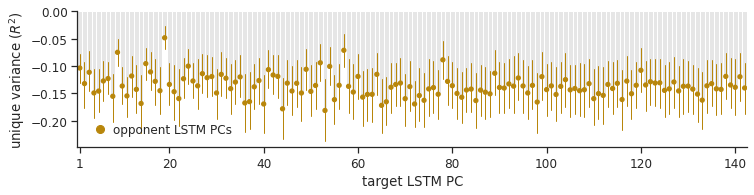

In [65]:
from matplotlib.lines import Line2D

scores_df = pd.read_csv(f'results/cvisc-nestedopp_lags-all_matchup-{matchup_id}_results.csv')

scores_df['unique'] = ((scores_df['joint score'] - 
                        scores_df['nested score']))

lag = 0
bar_width = 1

sns.set(style='ticks', font_scale=1.1)
#fig, ax = plt.subplots(figsize=(20, 4))
fig, ax = plt.subplots(figsize=(12, 2.5))
sns.barplot(x='PC', y='unique',
            data=scores_df[scores_melt['lag'] == lag],
            ci=None, color='.9', zorder=0,
            capsize=0, ax=ax)
for patch in ax.patches:
    curr_width = patch.get_width()
    diff_width = curr_width - bar_width
    patch.set_width(bar_width)
    patch.set_x(patch.get_x() + diff_width * .5)
sns.pointplot(x='PC', y='unique', errwidth=1,
              data=scores_df[scores_df['lag'] == lag],
              join=False, ax=ax, scale=.6, color='darkgoldenrod',
              legend='full')
ax.set(xlabel='target LSTM PC', ylabel='unique variance ($\it{R}^2$)')
       #ylim=(0, .8))
ax.set_xticks(np.insert(np.arange(20, n_pcs, 20) - 1, 0, 0))
ax.set_xticklabels(np.insert(np.arange(20, n_pcs, 20), 0, 1))
#handles, labels = ax.get_legend_handles_labels()
handles = [Line2D([0], [0], marker='o', markersize=8,
                  linestyle='', color='darkgoldenrod')]
labels = ['opponent LSTM PCs']
l = plt.legend(handles=handles, labels=labels, handletextpad=0,
               frameon=False)
#l.legendHandles[0]._sizes = [200]
sns.despine()
#plt.savefig(f'figures/cvisc-nestedopp_unique_lag-{lag}_data-v1_bar.svg', dpi=300, bbox_inches='tight', transparent=True)